# kinematic-dpca noise-floor results

Loads and plots the per-session output of `kinematic-dpca.py`. Point `RUN_TAG` at the run-tag folder the pipeline wrote (e.g. `lat_rauto_k10`).

In [3]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("../../")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import load

from tools.params import Params
import tools.dimensionality.dpca as dim
import tools.viz.utilityTools as vizutils

RUN_TAG = "lpt_rauto_k10"   # <-- the run-tag folder to visualize
RUN_DIR = Params.ACROSS_SESSION_RESULTS_DIR / "kinematic-dpca-noisefloor" / RUN_TAG
print(RUN_DIR)
print(sorted(p.name for p in RUN_DIR.glob("*")))

# marginalisation colours: time grey, level red, angle ('p') blue, interactions purple
GREY, RED, BLUE, PURPLE = "#9C9C9C", "#BB1419", "#0091E6", "#6B5BA1"


def marg_color(key):
    factors = set(key) - {"t"}
    if not factors:             # pure time / condition-independent
        return GREY
    if factors == {"l"}:        # level x time
        return RED
    if len(factors) == 1:       # a single non-level factor (angle 'p' / axis / direction)
        return BLUE
    return PURPLE               # any interaction (>1 factor)


/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/kinematic-dpca-noisefloor/lpt_rauto_k10
['M061_2025_03_04_10_00.npz', 'M061_2025_03_04_10_00_fit.joblib', 'M061_2025_03_05_14_00.npz', 'M061_2025_03_05_14_00_fit.joblib', 'M061_2025_03_06_14_00.npz', 'M061_2025_03_06_14_00_fit.joblib', 'M062_2025_03_20_14_00.npz', 'M062_2025_03_20_14_00_fit.joblib', 'M062_2025_03_21_14_00.npz', 'M062_2025_03_21_14_00_fit.joblib', 'M078_2025_08_06_15_00.npz', 'M078_2025_08_06_15_00_fit.joblib', 'M086_2025_12_10_15_00.npz', 'M086_2025_12_10_15_00_fit.joblib', 'M103_2026_02_18_15_30.npz', 'M103_2026_02_18_15_30_fit.joblib', 'M103_2026_02_19_15_30.npz', 'M103_2026_02_19_15_30_fit.joblib', 'M106_2026_02_25_15_00.npz', 'M106_2026_02_25_15_00_fit.joblib', 'summary.csv']


In [ ]:
# load every per-session .npz in the run folder
npz_files = sorted(RUN_DIR.glob("*.npz"))
assert npz_files, f"no per-session .npz in {RUN_DIR} -- run the pipeline for this RUN_TAG first"

S = {}
for f in npz_files:
    d = np.load(f, allow_pickle=True)
    S[str(d["session"])] = {k: d[k] for k in d.files}

sessions = list(S)
keys = list(S[sessions[0]]["keys"])            # marginalizations, e.g. ['t', 'lt', 'at', 'lat']

P  = np.array([S[s]["p"] for s in sessions])            # (n_sessions, n_marg)
Z  = np.array([S[s]["z"] for s in sessions])
SF = np.array([S[s]["signal_frac"] for s in sessions])
reg = np.array([float(S[s]["regularizer_used"]) for s in sessions])

print(len(sessions), "sessions | marginalizations:", keys)
# pd.DataFrame(P, index=sessions, columns=keys).assign(reg_used=reg).round(4)

10 sessions | marginalizations: [np.str_('t'), np.str_('lt'), np.str_('pt'), np.str_('lpt')]


In [3]:
# across-session aggregate written by the pipeline
df = pd.read_csv(RUN_DIR / "summary.csv")
df.style.format({c: "{:.2e}" for c in df.select_dtypes("float").columns})

,marg,n_sessions,n_animals,n_sig_sessions_p05,median_session_z,median_signal_frac,animal_mean_z,animal_z_ci_lo,animal_z_ci_hi,animal_z_p,sd_animal_z,n_animals_pos
0,t,10,6,0,-7.39e+00,4.39e-01,-8.11e+00,-1.13e+01,-4.93e+00,9.99e-01,3.03e+00,0
1,lt,10,6,8,3.97e+00,7.96e-02,3.41e+00,1.49e+00,5.33e+00,3.03e-03,1.83e+00,6
2,pt,10,6,10,8.36e+00,3.31e-01,1.03e+01,5.13e+00,1.56e+01,1.89e-03,4.97e+00,6
3,lpt,10,6,2,1.06e+00,1.22e-01,2.20e+00,-5.71e-01,4.97e+00,4.83e-02,2.64e+00,5


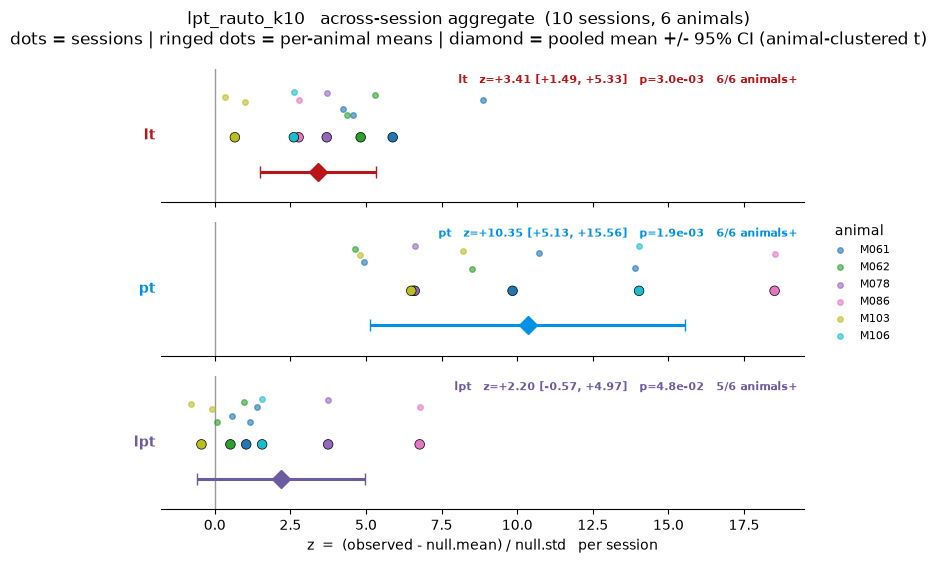

In [4]:
# ACROSS-SESSION AGGREGATE, one figure: per marginalisation (t skipped), each
# session's z as a dot coloured by animal, the per-animal means, and the pooled
# estimate +/- 95% CI from the animal-clustered t (same stat as summary.csv).
from scipy import stats as sps

marg_keys = [k for k in keys if k != "t"]
animals = np.array([s.split("_")[0] for s in sessions])
uniq = sorted(set(animals))
acol = dict(zip(uniq, plt.cm.tab10(np.linspace(0, 1, max(len(uniq), 3)))))
jit = np.random.default_rng(0).uniform(-0.11, 0.11, len(sessions))

fig, axs = plt.subplots(len(marg_keys), 1, figsize=(7, 1.9 * len(marg_keys)), sharex=True)
for ax, k in zip(np.atleast_1d(axs), marg_keys):
    zj = Z[:, keys.index(k)]                                  # per-session z
    amean = np.array([zj[animals == a].mean() for a in uniq])  # one number per animal
    g, sd = amean.mean(), amean.std(ddof=1)
    se = sd / np.sqrt(len(amean))
    tcrit = sps.t.ppf(0.975, len(amean) - 1)
    pval = sps.t.sf(g / se, len(amean) - 1) if se > 0 else np.nan  # one-sided, H1: g > 0

    ax.axvline(0, color="0.6", lw=1)
    for a in uniq:                                            # individual sessions
        m = animals == a
        ax.scatter(zj[m], 0.25 + jit[m], s=16, color=acol[a], alpha=0.6, label=a, zorder=3)
    ax.scatter(amean, np.full(len(amean), -0.05), s=48,       # per-animal means
               color=[acol[a] for a in uniq], edgecolor="k", linewidth=0.5, zorder=4)
    ax.errorbar(g, -0.35, xerr=tcrit * se, fmt="D", ms=9, color=marg_color(k),  # pooled +/- 95% CI
                ecolor=marg_color(k), elinewidth=2.2, capsize=4, zorder=5)
    ax.text(0.99, 0.96,
            f"{k}   z={g:+.2f} [{g - tcrit * se:+.2f}, {g + tcrit * se:+.2f}]   "
            f"p={pval:.1e}   {(amean > 0).sum()}/{len(amean)} animals+",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            color=marg_color(k), fontweight="bold")
    ax.set_yticks([]); ax.set_ylim(-0.62, 0.55)
    ax.set_ylabel(k, color=marg_color(k), rotation=0, ha="right", va="center", fontweight="bold")
    ax.spines[["top", "right", "left"]].set_visible(False)

np.atleast_1d(axs)[-1].set_xlabel("z  =  (observed - null.mean) / null.std   per session")
h, lab = np.atleast_1d(axs)[0].get_legend_handles_labels()
by = dict(zip(lab, h))
fig.legend(by.values(), by.keys(), title="animal", loc="center left",
           bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=8)
fig.suptitle(f"{RUN_TAG}   across-session aggregate  ({len(sessions)} sessions, {len(uniq)} animals)\n"
             "dots = sessions | ringed dots = per-animal means | diamond = pooled mean +/- 95% CI (animal-clustered t)")
fig.tight_layout()


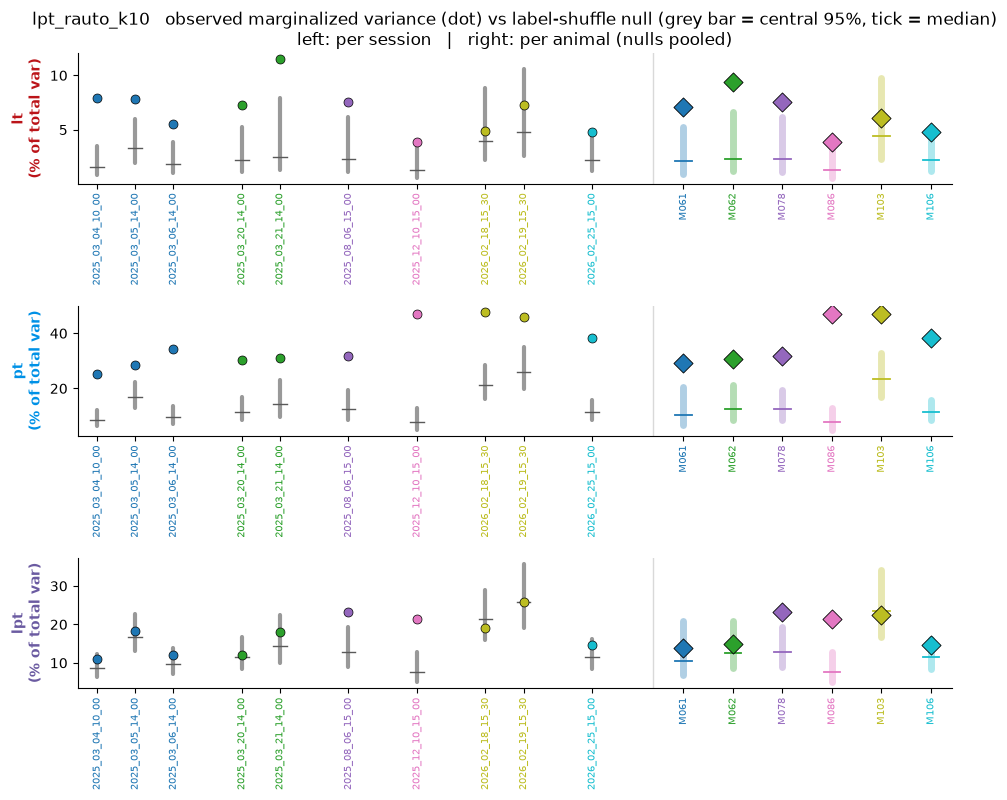

In [5]:
# ONE figure: observed marginalized variance (dots) vs its label-shuffle null
# (grey bar = central 95%, tick = median), on the raw "% of total variance" scale.
# Left block = per session (grouped/coloured by animal); right block = per animal
# (nulls pooled across that animal's sessions, observed = mean of its sessions).
marg_keys = [k for k in keys if k != "t"]
animals = np.array([s.split("_")[0] for s in sessions])
uniq = sorted(set(animals))
acol = dict(zip(uniq, plt.cm.tab10(np.linspace(0, 1, max(len(uniq), 3)))))
order = sorted(range(len(sessions)), key=lambda ii: (animals[ii], sessions[ii]))

fig, axs = plt.subplots(len(marg_keys), 1,
                        figsize=(0.42 * (len(sessions) + len(uniq)) + 3, 2.7 * len(marg_keys)))
for ax, k in zip(np.atleast_1d(axs), marg_keys):
    j = keys.index(k)
    col = marg_color(k)
    xt, xtl, xtc = [], [], []

    x, prev = 0.0, None
    for ii in order:                                   # ---- per session ----
        s, a = sessions[ii], animals[ii]
        if prev is not None and a != prev:
            x += 0.8
        prev = a
        nl, ob = S[s]["null"][:, j], S[s]["observed"][j]
        lo, md, hi = np.percentile(nl, [2.5, 50, 97.5])
        ax.plot([x, x], [lo, hi], color="0.6", lw=3, solid_capstyle="round", zorder=2)
        ax.plot([x - 0.18, x + 0.18], [md, md], color="0.35", lw=1, zorder=3)
        ax.scatter([x], [ob], s=42, color=acol[a], edgecolor="k", linewidth=0.5, zorder=4)
        xt.append(x); xtl.append(s.split("_", 1)[1]); xtc.append(acol[a])
        x += 1

    sep = x + 0.6
    ax.axvline(sep, color="0.85", lw=1)
    x = sep + 0.8
    for a in uniq:                                     # ---- per animal (pooled) ----
        idx = [ii for ii in range(len(sessions)) if animals[ii] == a]
        nl = np.concatenate([S[sessions[ii]]["null"][:, j] for ii in idx])
        ob = np.mean([S[sessions[ii]]["observed"][j] for ii in idx])
        lo, md, hi = np.percentile(nl, [2.5, 50, 97.5])
        ax.plot([x, x], [lo, hi], color=acol[a], lw=5, alpha=0.35, solid_capstyle="round", zorder=2)
        ax.plot([x - 0.22, x + 0.22], [md, md], color=acol[a], lw=1.3, zorder=3)
        ax.scatter([x], [ob], s=95, marker="D", color=acol[a], edgecolor="k", linewidth=0.6, zorder=5)
        xt.append(x); xtl.append(a); xtc.append(acol[a])
        x += 1.3

    ax.set_xticks(xt); ax.set_xticklabels(xtl, rotation=90, fontsize=7)
    for tl, c in zip(ax.get_xticklabels(), xtc):
        tl.set_color(c)
    ax.set_ylabel(f"{k}\n(% of total var)", color=col, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.margins(x=0.015)

np.atleast_1d(axs)[0].set_title(
    f"{RUN_TAG}   observed marginalized variance (dot) vs label-shuffle null "
    "(grey bar = central 95%, tick = median)\nleft: per session   |   right: per animal (nulls pooled)")
fig.tight_layout()


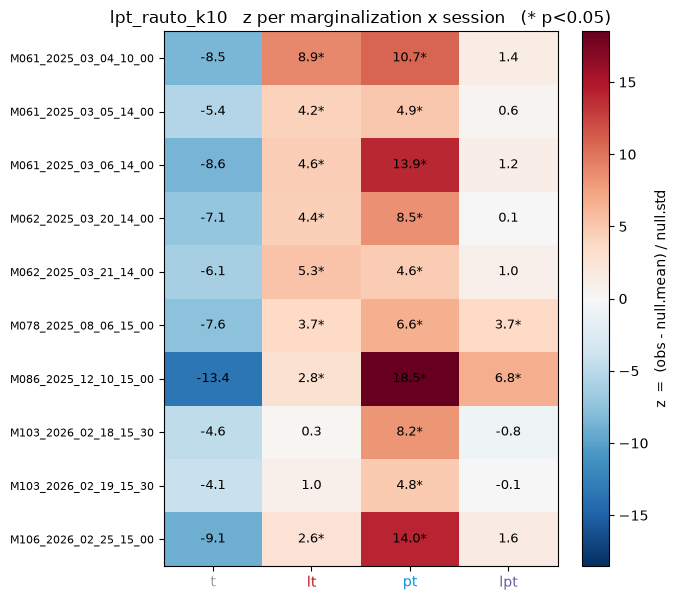

In [6]:
# z per marginalization x session; * marks p < 0.05 (x-ticks tinted by marginalisation)
vmax = np.nanmax(np.abs(Z))
fig, ax = plt.subplots(figsize=(1.2 * len(keys) + 2, 0.45 * len(sessions) + 1.6))
im = ax.imshow(Z, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(len(keys)), keys)
for tl, k in zip(ax.get_xticklabels(), keys):
    tl.set_color(marg_color(k))
ax.set_yticks(range(len(sessions)), sessions, fontsize=8)
for i in range(len(sessions)):
    for j in range(len(keys)):
        star = "*" if P[i, j] < 0.05 else ""
        ax.text(j, i, f"{Z[i, j]:.1f}{star}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, label="z  =  (obs - null.mean) / null.std")
ax.set_title(f"{RUN_TAG}   z per marginalization x session   (* p<0.05)")
fig.tight_layout()


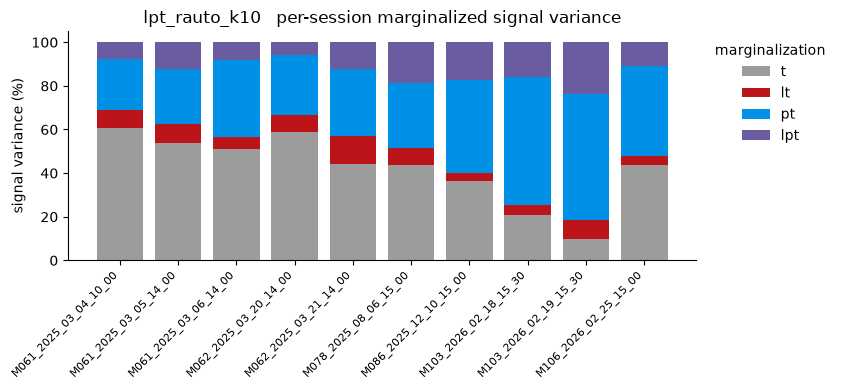

In [7]:
# per-session composition: stacked noise-corrected signal-variance fraction by
# marginalization (each bar = one session, sums to 100%)
frac = SF * 100                                   # (n_sessions, n_marg), rows ~ sum to 100

fig, ax = plt.subplots(figsize=(0.55 * len(sessions) + 3, 4))
bottom = np.zeros(len(sessions))
for j, k in enumerate(keys):
    ax.bar(range(len(sessions)), frac[:, j], bottom=bottom, width=0.8,
           color=marg_color(k), label=str(k))
    bottom += frac[:, j]
ax.set_xticks(range(len(sessions)))
ax.set_xticklabels(sessions, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("signal variance (%)")
ax.set_title(f"{RUN_TAG}   per-session marginalized signal variance")
ax.legend(title="marginalization", bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()


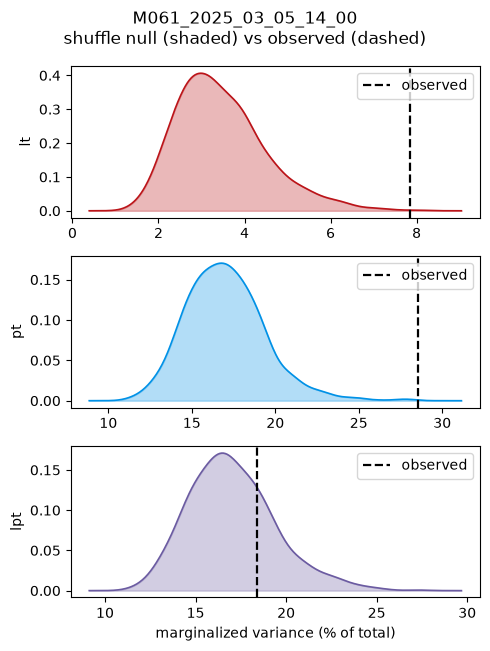

In [6]:
# one session: label-shuffle null (KDE) vs observed (dashed), one row per
# marginalisation -- the condition-independent 't' bucket is skipped
from scipy.stats import gaussian_kde

sess = sessions[1]                              # <-- choose a session
d = S[sess]
null, observed, p = d["null"], d["observed"], d["p"]
marg_keys = [k for k in keys if k != "t"]

fig, axs = plt.subplots(len(marg_keys), 1, figsize=(5, 2.2 * len(marg_keys)))
for ax, k in zip(np.atleast_1d(axs), marg_keys):
    i = keys.index(k)
    col = marg_color(k)
    xs = null[:, i]
    lo = min(xs.min(), observed[i]); hi = max(xs.max(), observed[i]); pad = 0.15 * (hi - lo + 1e-9)
    grid = np.linspace(lo - pad, hi + pad, 400)
    dens = gaussian_kde(xs)(grid)
    ax.fill_between(grid, dens, color=col, alpha=0.30)
    ax.plot(grid, dens, color=col, lw=1.2)
    ax.axvline(observed[i], color="k", ls="--", lw=1.6, label='observed')
    lab = f"p={p[i]:.3f}" if p[i] > 1 / null.shape[0] else f"p<{1 / null.shape[0]:.3f}"
    ax.set_ylabel(k)
    # ax.text(0.98, 0.92, f"{k}   obs={observed[i]:.2f}   {lab}", transform=ax.transAxes,
    #         ha="right", va="top", fontsize=8, color=col, fontweight="bold")
    # ax.set_yticks([])
    # ax.spines[["top", "right", "left"]].set_visible(False)
    ax.legend()
np.atleast_1d(axs)[-1].set_xlabel("marginalized variance (% of total)")
fig.suptitle(f"{sess}\nshuffle null (shaded) vs observed (dashed)")
fig.tight_layout()


Text(0.5, 1.0, 'M061_2025_03_05_14_00\nmarginalized signal variance')

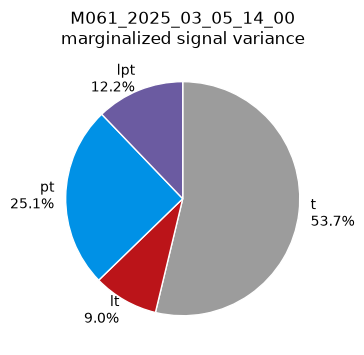

In [9]:
# noise-corrected signal variance per marginalization (Kobak 2016 Fig 3-6d)
frac = d["signal_frac"] * 100
fig, ax = plt.subplots(figsize=(3.8, 3.8))
ax.pie(frac, colors=[marg_color(k) for k in keys],
       labels=[f"{k}\n{v:.1f}%" for k, v in zip(keys, frac)],
       startangle=90, counterclock=False, wedgeprops=dict(edgecolor="w", linewidth=1))
ax.set_title(f"{sess}\nmarginalized signal variance")


## Session specific

In [33]:
X.shape

(57, 2, 6, 200)

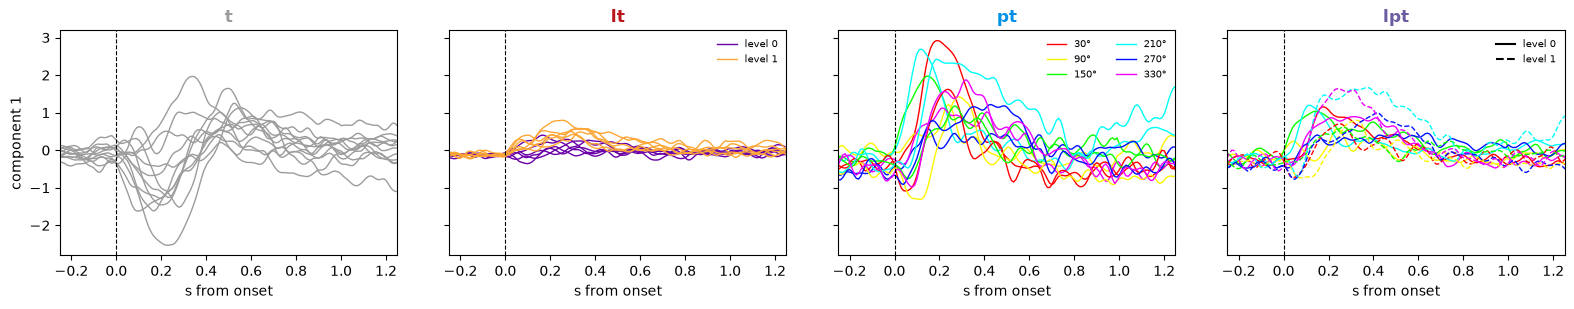

In [12]:
# first demixed component per marginalization -- ALL level x angle traces shown in
# every panel, coloured by that marginalization's own factor, so you can see which
# conditions it actually separates (2-factor level x angle model, e.g. labels='lpt')
b = load(RUN_DIR / f"{sess}_fit.joblib")
m, X, cond_values = b["dpca"], b["X_psth"], b["cond_values"]
levels, angles = cond_values[0], cond_values[1]           # sorted level values, angle values (deg)
Zc = m.transform(X)                                       # key -> (n_comp, n_level, n_angle, n_time)
t = np.arange(X.shape[-1]) / 100 - 0.5                    # s from onset (RESPONSE window)

level_cols = plt.cm.plasma(np.linspace(0.2, 0.8, len(levels)))
angle_cols = plt.cm.hsv(np.linspace(0, 1, len(angles), endpoint=False))

fig, axs = plt.subplots(1, len(keys), figsize=(4 * len(keys), 3.2), squeeze=False, sharey="all", sharex='all')
for ax, k in zip(axs[0], keys):
    C = Zc[k][1]                                          # (n_level, n_angle, n_time)
    fac = set(k) - {"t"}
    for li in range(len(levels)):
        for ai in range(len(angles)):
            if not fac:                                   # time -> every trace grey (should overlap)
                ax.plot(t, C[li, ai], color=GREY, lw=1)
            elif fac == {"l"}:                            # level -> colour by level; angle is the within-colour spread
                ax.plot(t, C[li, ai], color=level_cols[li], lw=1,
                        label=f"level {levels[li]}" if ai == 0 else None)
            elif len(fac) == 1:                           # angle -> colour by angle; level is the within-colour spread
                ax.plot(t, C[li, ai], color=angle_cols[ai], lw=1,
                        label=f"{angles[ai]}\u00b0" if li == 0 else None)
            else:                                         # interaction -> colour by angle, dash by level
                ax.plot(t, C[li, ai], color=angle_cols[ai], lw=1,
                        ls="-" if li == 0 else "--")
    if fac == {"l"}:
        ax.legend(fontsize=7, frameon=False)
    elif len(fac) == 1 and fac:
        ax.legend(fontsize=7, ncol=2, frameon=False)
    elif len(fac) > 1:
        ax.plot([], [], color="k", ls="-", label=f"level {levels[0]}")
        ax.plot([], [], color="k", ls="--", label=f"level {levels[-1]}")
        ax.legend(fontsize=7, frameon=False)
    ax.axvline(0, color="k", ls="dashed", lw=0.8)
    ax.set_title(k, color=marg_color(k), fontweight="bold")
    ax.set_xlabel("s from onset")
axs[0, 0].set_ylabel("component 1")
axs[0, 0].set_xlim(-0.25, 1.25)
fig.tight_layout()


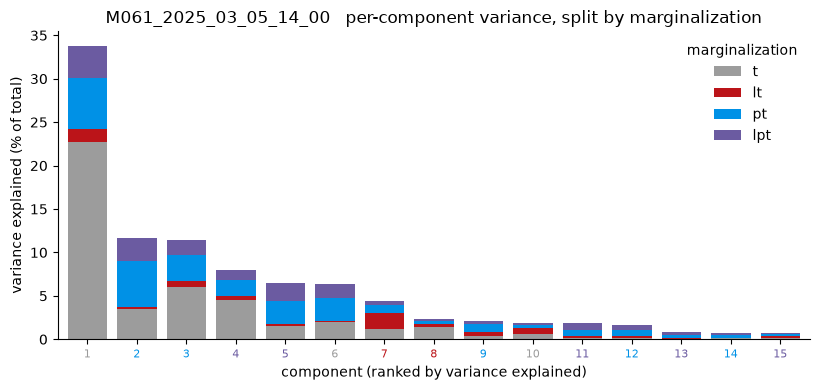

In [8]:
# per-component variance contribution for `sess` (Kobak 2016 Fig 3-6 bar plot):
# every demixed component ranked by total variance explained, each bar split by
# the marginalisation it explains variance in. Uses `m` / `X` from the cell above.
componentVar, margVar, whichMarg, order = dim.get_var_split(m, X)   # margVar: (n_marg, n_comp), var-ranked
n_show = min(15, len(componentVar))
x = np.arange(1, n_show + 1)

fig, ax = plt.subplots(figsize=(0.42 * n_show + 2, 4))
bottom = np.zeros(n_show)
for j, k in enumerate(keys):
    ax.bar(x, margVar[j, :n_show], bottom=bottom, width=0.8, color=marg_color(k), label=str(k))
    bottom += margVar[j, :n_show]
ax.set_xticks(x, x, fontsize=8)
for tl, k in zip(ax.get_xticklabels(), whichMarg[:n_show]):   # tint tick by the component's dominant marginalisation
    tl.set_color(marg_color(str(k)))
ax.set_xlim(0.4, n_show + 0.6)
ax.set_xlabel("component (ranked by variance explained)")
ax.set_ylabel("variance explained (% of total)")
ax.set_title(f"{sess}   per-component variance, split by marginalization")
ax.legend(title="marginalization", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()


In [4]:
sess = 'M061_2025_03_05_14_00'
b = load(RUN_DIR / f"{sess}_fit.joblib")
m, X, cond_values = b["dpca"], b["X_psth"], b["cond_values"]
feat = np.load(Params.ACROSS_SESSION_RESULTS_DIR / "cache" / f"{sess}.npz",
               allow_pickle=True)["labels"]

In [5]:
feat

array(['left_ankle_rc', 'left_ankle_vt', 'left_ankle_ml', 'left_elbow_rc',
       'left_elbow_vt', 'left_elbow_ml', 'left_foot_rc', 'left_foot_vt',
       'left_foot_ml', 'left_knee_rc', 'left_knee_vt', 'left_knee_ml',
       'left_paw_rc', 'left_paw_vt', 'left_paw_ml', 'left_wrist_rc',
       'left_wrist_vt', 'left_wrist_ml', 'left_shoulder_rc',
       'left_shoulder_vt', 'left_shoulder_ml', 'right_ankle_rc',
       'right_ankle_vt', 'right_ankle_ml', 'right_elbow_rc',
       'right_elbow_vt', 'right_elbow_ml', 'right_foot_rc',
       'right_foot_vt', 'right_foot_ml', 'right_knee_rc', 'right_knee_vt',
       'right_knee_ml', 'right_paw_rc', 'right_paw_vt', 'right_paw_ml',
       'right_wrist_rc', 'right_wrist_vt', 'right_wrist_ml',
       'right_shoulder_rc', 'right_shoulder_vt', 'right_shoulder_ml',
       'shoulder_center_rc', 'shoulder_center_vt', 'shoulder_center_ml',
       'hip_center_rc', 'hip_center_vt', 'hip_center_ml', 'tail_base_rc',
       'tail_base_vt', 'tail_base_ml', '

In [6]:
dm   = np.array([f.rsplit("_", 1)[1] for f in feat])   # 'rc' / 'vt' / 'ml'
rc_mask = dm == "rc"
vt_mask = dm == "vt"
ml_mask = dm == "ml"

In [7]:
m.P['pt'][:, 0][rc_mask]

array([ 2.14478321e-02,  6.45927559e-03,  1.06601846e-02,  2.89763487e-02,
        8.81346303e-03,  7.86848432e-03, -2.62545136e-02, -2.73002558e-02,
       -3.83572745e-02, -2.88725204e-02, -4.07213324e-02, -2.39823665e-02,
       -2.82562943e-02, -3.10928503e-02, -5.68932339e-02, -6.33621484e-03,
        4.15966964e-02, -7.80506188e-05, -2.77092240e-02])

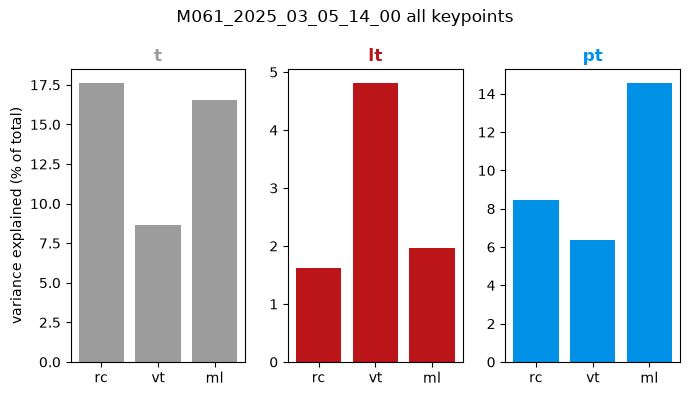

In [13]:
componentVar, margVar, whichMarg, order = dim.get_var_split(m, X)     # componentVar is %-of-total, in `order`
Fall = np.hstack([m.P[k] for k in keys])[:, order]                     # encoders aligned to componentVar order

dim_masks = {"rc": rc_mask, "vt": vt_mask, "ml": ml_mask}
kp_of = np.array([f.rsplit("_", 1)[0] for f in feat])
DROP_KP = {"tail_base", "tail_middle", "tail_tip", "shoulder_center"}
keep_kp = ~np.isin(kp_of, list(DROP_KP))                              # exclude tail + shoulder_center

fig, axs = plt.subplots(1, 3, figsize=(7, 4))
for ax, marg in zip(axs, ['t', 'lt', 'pt']):
    cols = whichMarg == marg
    componentVars = componentVar[cols]
    ys = []
    for dim_ in dim_masks.values():
        sel = dim_ #& keep_kp
        sum_weights = (Fall[sel][:, cols] ** 2 * componentVars[None, :]).sum(1)
        ys.append(sum_weights.sum())
    ax.bar(list(dim_masks.keys()), ys, color=marg_color(marg))
    ax.set_title(marg, color=marg_color(marg), fontweight="bold")
axs[0].set_ylabel("variance explained (% of total)")
fig.suptitle(f"{sess} all keypoints")
fig.tight_layout()


In [14]:
componentVar.shape

(40,)

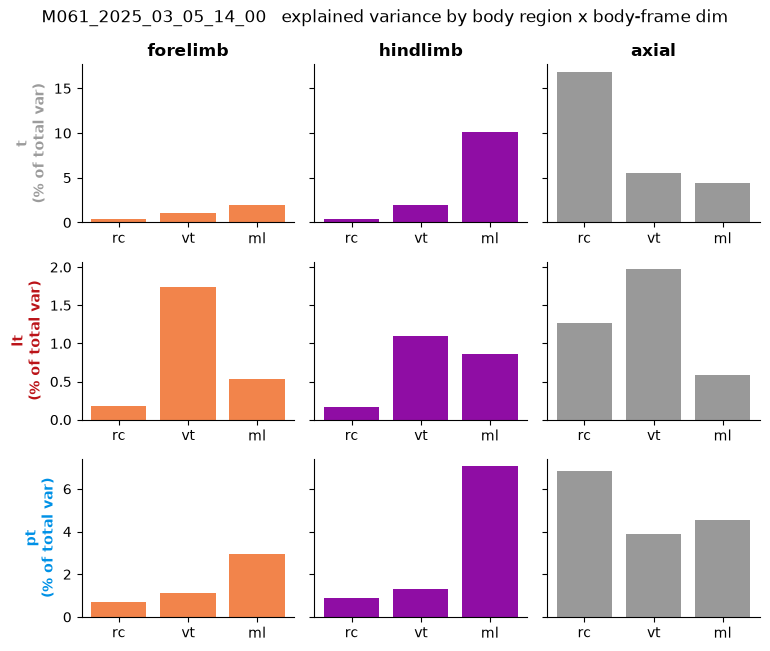

In [15]:
# explained-variance proxy (sum_c componentVar[c] * F[feat,c]**2, SUMMED over a group's
# features) by body region x body-frame dim, per marginalization.
# rows = t / lt / pt ; cols = forelimb / hindlimb / axial ; bars = rc / vt / ml.
import matplotlib.cm as cm

kp_of  = np.array([f.rsplit("_", 1)[0] for f in feat])
dim_of = np.array([f.rsplit("_", 1)[1] for f in feat])

FORE  = {"left_elbow", "left_wrist", "left_paw", "right_elbow", "right_wrist", "right_paw"}
HIND  = {"left_ankle", "left_knee", "left_foot", "right_ankle", "right_knee", "right_foot"}
AXIAL = {"tail_base", "tail_middle", "tail_tip", "hip_center", "shoulder_center",
         "left_shoulder", "right_shoulder"}
groups = {"forelimb": np.isin(kp_of, list(FORE)),
          "hindlimb": np.isin(kp_of, list(HIND)),
          "axial":    np.isin(kp_of, list(AXIAL))}
gcol = {"forelimb": cm.plasma(0.7), "hindlimb": cm.plasma(0.3), "axial": "0.6"}
dims = ["rc", "vt", "ml"]

componentVar, margVar, whichMarg, order = dim.get_var_split(m, X)
keys = ['t', 'lt', 'pt', 'lpt']
Fall = np.hstack([m.P[k] for k in keys])[:, order]

rows = ["t", "lt", "pt"]
fig, axs = plt.subplots(len(rows), len(groups), figsize=(2.6 * len(groups), 2.2 * len(rows)),
                        sharey="row", squeeze=False)
for ri, marg in enumerate(rows):
    cols = whichMarg == marg
    cv = componentVar[cols]
    for ci, (gname, gmask) in enumerate(groups.items()):
        ax = axs[ri, ci]
        ys = [(Fall[gmask & (dim_of == d)][:, cols] ** 2 * cv[None, :]).sum() for d in dims]
        ax.bar(dims, ys, color=gcol[gname])
        if ri == 0:
            ax.set_title(gname, fontweight="bold")
        if ci == 0:
            ax.set_ylabel(f"{marg}\n(% of total var)", color=marg_color(marg), fontweight="bold")
        ax.spines[["top", "right"]].set_visible(False)
fig.suptitle(f"{sess}   explained variance by body region x body-frame dim")
fig.tight_layout()


forelimb
hindlimb
axial
forelimb
hindlimb
axial
forelimb
hindlimb
axial


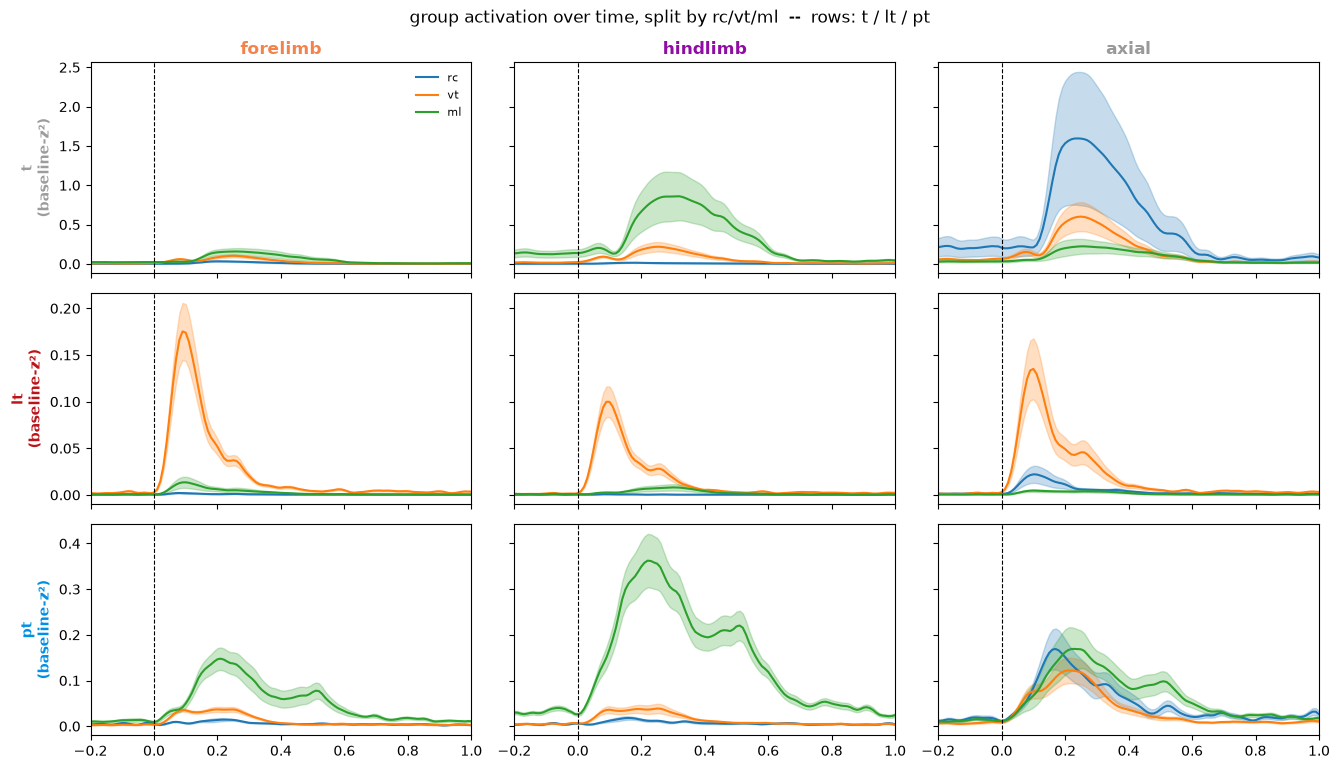

In [21]:
# group activation over time, split by rc / vt / ml, for t / lt / pt (3x3 grid).
# Per marginalization we collapse the condition axis with MEAN-OF-SQUARES, not
# square-of-mean: for 't' the conditions are near-replicates so it barely matters,
# but for 'lt'/'pt' the condition axis carries REAL signal (level, angle resp.) and
# a plain mean risks sign cancellation across it -- squaring first avoids that
# uniformly, without having to hand-identify which axis is redundant per marg.
ROWS = ["t", "lt", "pt"]
dim_cols = dict(zip(["rc", "vt", "ml"], plt.cm.tab10([0, 1, 2])))

fig, axs = plt.subplots(len(ROWS), len(groups), figsize=(4.5 * len(groups), 2.6 * len(ROWS)),
                        sharey="row", squeeze=False, sharex='all')
for ri, marg in enumerate(ROWS):
    Z_marg = Zc[marg].reshape(Zc[marg].shape[0], -1, Zc[marg].shape[-1])   # (n_comp, n_cond, n_time)
    w = np.tensordot(m.P[marg], Z_marg, axes=([1], [0]))                  # (57, n_cond, n_time) -- components summed
    energy_cond = (w ** 2).mean(axis=1)                                    # mean-of-squares over conditions -> (57, n_time)
    for ci, (gname, gmask) in enumerate(groups.items()):
        print(gname)
        ax = axs[ri, ci]
        for dname, dcol in dim_cols.items():
            sel = gmask & (dim_of == dname)
            e = energy_cond[sel]                                          # (n_feat_in_group_dim, n_time)
            mean_e = e.mean(0)
            sem_e  = e.std(0, ddof=1) / np.sqrt(e.shape[0])
            ax.plot(t, mean_e, color=dcol, label=dname)
            ax.fill_between(t, mean_e - sem_e, mean_e + sem_e, color=dcol, alpha=0.25)
        ax.axvline(0, color="k", ls="dashed", lw=0.8)
        if ri == 0:
            ax.set_title(gname, color=gcol[gname], fontweight="bold")
        if ci == 0:
            ax.set_ylabel(f"{marg}\n(baseline-z\u00b2)", color=marg_color(marg), fontweight="bold")
axs[0, 0].legend(frameon=False, fontsize=8)
axs[0, 0].set_xlim(-0.2, 1)
fig.suptitle("group activation over time, split by rc/vt/ml  --  rows: t / lt / pt")
fig.tight_layout()


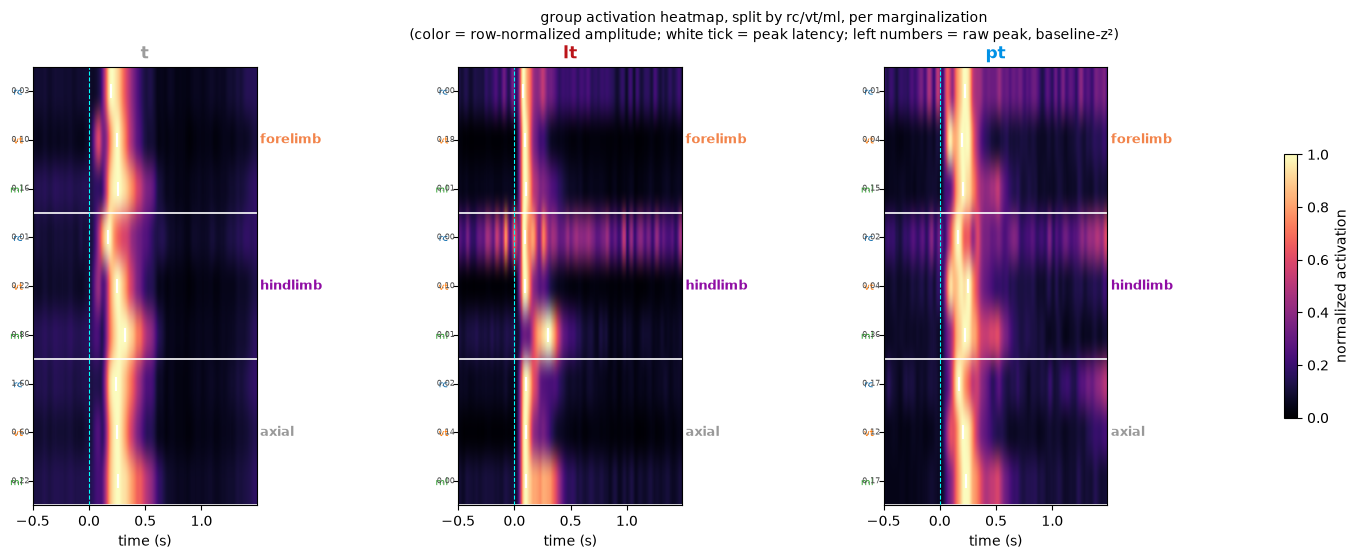

In [19]:
ROWS = ["t", "lt", "pt"]
DIMS = ["rc", "vt", "ml"]
dim_cols = dict(zip(DIMS, plt.cm.tab10([0, 1, 2])))

fig, axs = plt.subplots(1, len(ROWS), figsize=(6.5 * len(ROWS), 0.5 * len(groups) * len(DIMS) + 1.2),
                        squeeze=False)
axs = axs[0]

for ri, marg in enumerate(ROWS):
    ax = axs[ri]
    Z_marg = Zc[marg].reshape(Zc[marg].shape[0], -1, Zc[marg].shape[-1])
    w = np.tensordot(m.P[marg], Z_marg, axes=([1], [0]))
    energy_cond = (w ** 2).mean(axis=1)  # (57, n_time)

    rows, row_labels, row_label_colors, peak_amps, group_bounds = [], [], [], [], [0]
    for gname, gmask in groups.items():
        for dname in DIMS:
            sel = gmask & (dim_of == dname)
            mean_e = energy_cond[sel].mean(0)
            peak_amps.append(mean_e.max())
            rows.append(mean_e / (mean_e.max() + 1e-12))  # row-normalized for visibility
            row_labels.append(dname)
            row_label_colors.append(dim_cols[dname])
        group_bounds.append(group_bounds[-1] + len(DIMS))

    M = np.array(rows)
    im = ax.imshow(M, aspect="auto", cmap="magma", vmin=0, vmax=1,
                    extent=[t[0], t[-1], M.shape[0], 0])

    # peak-latency ticks
    for ridx, mean_e_norm in enumerate(M):
        pk = np.argmax(mean_e_norm)
        if t[pk] > 0:
            ax.plot(t[pk], ridx + 0.5, "|", color="white", ms=10, mew=1.5)

    # group separators + labels
    for gi, gname in enumerate(groups.keys()):
        y0, y1 = group_bounds[gi], group_bounds[gi + 1]
        ax.axhline(y1, color="white", lw=1.2)
        ax.text(t[-1] + 0.03, (y0 + y1) / 2, gname, va="center", ha="left",
                color=gcol[gname], fontweight="bold", fontsize=9,
                transform=ax.transData, clip_on=False)

    ax.set_yticks(np.arange(len(row_labels)) + 0.5)
    ax.set_yticklabels(row_labels, fontsize=7)
    for tick, c in zip(ax.get_yticklabels(), row_label_colors):
        tick.set_color(c)

    # raw peak amplitude annotated per row (keeps magnitude story despite normalization)
    for ridx, amp in enumerate(peak_amps):
        ax.text(t[0] - 0.03, ridx + 0.5, f"{amp:.2f}", va="center", ha="right",
                fontsize=6, color="0.3", transform=ax.transData, clip_on=False)

    ax.axvline(0, color="cyan", ls="dashed", lw=0.8)
    ax.set_xlim(t[0], t[-1])
    ax.set_title(marg, color=marg_color(marg), fontweight="bold")
    ax.set_xlabel("time (s)")

fig.suptitle("group activation heatmap, split by rc/vt/ml, per marginalization\n"
             "(color = row-normalized amplitude; white tick = peak latency; "
             "left numbers = raw peak, baseline-z\u00b2)", fontsize=10)
fig.subplots_adjust(right=0.88, wspace=0.9)
cbar = fig.colorbar(im, ax=axs, shrink=0.6, pad=0.12)
cbar.set_label("normalized activation")

In [55]:
componentVar[0]

np.float64(33.77048772295383)

In [58]:
Z_t.shape

(10, 12, 200)

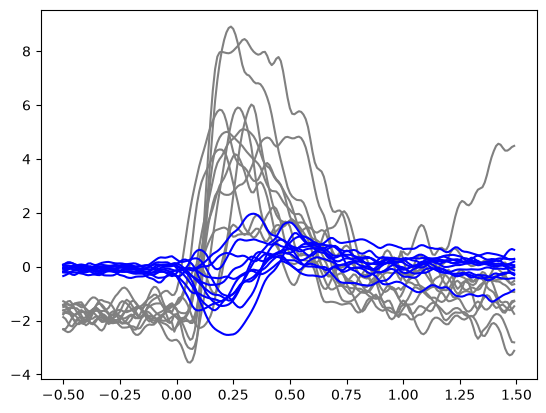

In [106]:
Zc['t'].shape

Z_t = Zc['t'].reshape(10, -1, 200)
fig, ax = plt.subplots()
ax.plot(t, Z_t[0, :, :].T, color='grey')
ax.plot(t, Z_t[1, :, :].T, color='blue')

plt.show()

# fig, ax = plt.subplots()
# im = ax.imshow()

In [107]:
feat = np.load(Params.ACROSS_SESSION_RESULTS_DIR / "cache" / f"{sess}.npz",
               allow_pickle=True)["labels"]
kp_of  = np.array([f.rsplit("_", 1)[0] for f in feat])
dim_of = np.array([f.rsplit("_", 1)[1] for f in feat])

FORE  = {"left_elbow", "left_wrist", "left_paw", "right_elbow", "right_wrist", "right_paw"}
HIND  = {"left_ankle", "left_knee", "left_foot", "right_ankle", "right_knee", "right_foot"}
AXIAL = {"tail_base", "tail_middle", "tail_tip", "hip_center", "shoulder_center",
         "left_shoulder", "right_shoulder"}
groups = {"forelimb": np.isin(kp_of, list(FORE)),
          "hindlimb": np.isin(kp_of, list(HIND)),
          "axial":    np.isin(kp_of, list(AXIAL))}
gcol = {"forelimb": cm.plasma(0.7), "hindlimb": cm.plasma(0.3), "axial": "0.6"}
dims = ["rc", "vt", "ml"]

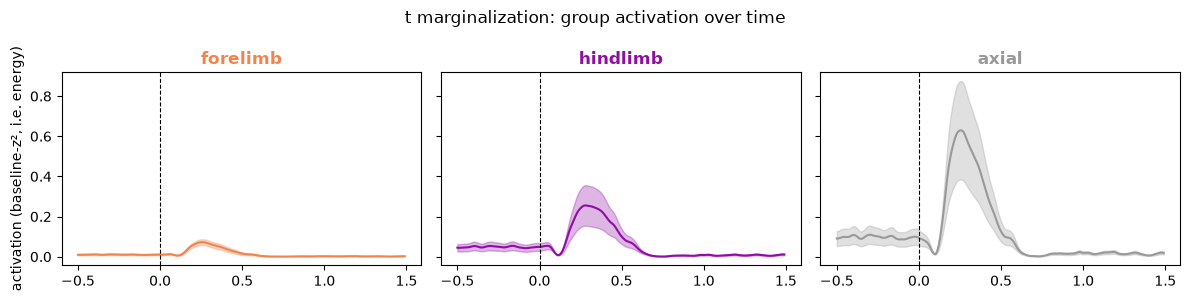

In [109]:
w_t = np.tensordot(m.P['t'], Z_t, axes=([1], [0]))   # (57, 12, 200) -- components already summed
w_t_c = w_t.mean(axis=1)                              # average over conditions (redundant for 't') -> (57, 200)

fig, axs = plt.subplots(1, len(groups), figsize=(4*len(groups), 3), sharey=True)
for ax, (gname, gmask) in zip(axs, groups.items()):
    sq = w_t_c[gmask] ** 2                            # (n_group_feat, 200) -- per-feature energy over time
    mean_e = sq.mean(0)                               # (200,) group mean energy
    sem_e  = sq.std(0, ddof=1) / np.sqrt(sq.shape[0])  # (200,) feature-to-feature SEM, same (squared) units
    ax.plot(t, mean_e, color=gcol[gname])
    ax.fill_between(t, mean_e - sem_e, mean_e + sem_e, color=gcol[gname], alpha=0.3)
    ax.set_title(gname, color=gcol[gname], fontweight="bold")
    ax.axvline(0, color="k", ls="dashed", lw=0.8)
axs[0].set_ylabel("activation (baseline-z², i.e. energy)")
fig.suptitle("t marginalization: group activation over time")
fig.tight_layout()

In [110]:
# --- region x dim x marginalization proxy for EVERY session, plus helpers ---
import matplotlib.cm as cm

ROWS  = ["t", "lt", "pt"]
DIMS  = ["rc", "vt", "ml"]
FORE  = {"left_elbow", "left_wrist", "left_paw", "right_elbow", "right_wrist", "right_paw"}
HIND  = {"left_ankle", "left_knee", "left_foot", "right_ankle", "right_knee", "right_foot"}
AXIAL = {"tail_base", "tail_middle", "tail_tip", "hip_center", "shoulder_center",
         "left_shoulder", "right_shoulder"}

feat0  = np.load(Params.ACROSS_SESSION_RESULTS_DIR / "cache" / f"{sessions[0]}.npz",
                 allow_pickle=True)["labels"]                       # shared across sessions
kp0    = np.array([f.rsplit("_", 1)[0] for f in feat0])
dim0   = np.array([f.rsplit("_", 1)[1] for f in feat0])
GROUPS = {"forelimb": np.isin(kp0, list(FORE)),
          "hindlimb": np.isin(kp0, list(HIND)),
          "axial":    np.isin(kp0, list(AXIAL))}
GCOL   = {"forelimb": cm.plasma(0.65), "hindlimb": cm.plasma(0.35), "axial": "0.6"}


def region_dim_table(mm, XX):
    """(n_marg, n_group, n_dim) proxy contribution: sum_c componentVar[c]*F[feat,c]**2,
    summed over each region x body-frame-dim group. % of total variance."""
    cV, _, wM, order = dim.get_var_split(mm, XX)
    Fall = np.hstack([mm.P[k] for k in list(mm.marginalizations)])[:, order]
    T = np.zeros((len(ROWS), len(GROUPS), len(DIMS)))
    for ri, marg in enumerate(ROWS):
        cols = wM == marg
        cv = cV[cols]
        for ci, gm in enumerate(GROUPS.values()):
            for di, d in enumerate(DIMS):
                T[ri, ci, di] = (Fall[gm & (dim0 == d)][:, cols] ** 2 * cv[None, :]).sum()
    return T


def plot_region_dim(T, title, err=None):
    fig, axs = plt.subplots(len(ROWS), len(GROUPS), figsize=(2.6 * len(GROUPS), 2.1 * len(ROWS)),
                            sharey="row", squeeze=False)
    for ri, marg in enumerate(ROWS):
        for ci, (gname, _) in enumerate(GROUPS.items()):
            ax = axs[ri, ci]
            ax.bar(DIMS, T[ri, ci], yerr=None if err is None else err[ri, ci],
                   color=GCOL[gname], capsize=3)
            if ri == 0:
                ax.set_title(gname, fontweight="bold")
            if ci == 0:
                ax.set_ylabel(f"{marg}\n(% total var)")
            ax.spines[["top", "right"]].set_visible(False)
    fig.suptitle(title)
    fig.tight_layout()


Tall = []
for s in sessions:
    bb = load(RUN_DIR / f"{s}_fit.joblib")
    Tall.append(region_dim_table(bb["dpca"], bb["X_psth"]))
Tall = np.stack(Tall)
print("Tall", Tall.shape, "(n_sessions, marg, group, dim)")


Tall (10, 3, 3, 3) (n_sessions, marg, group, dim)


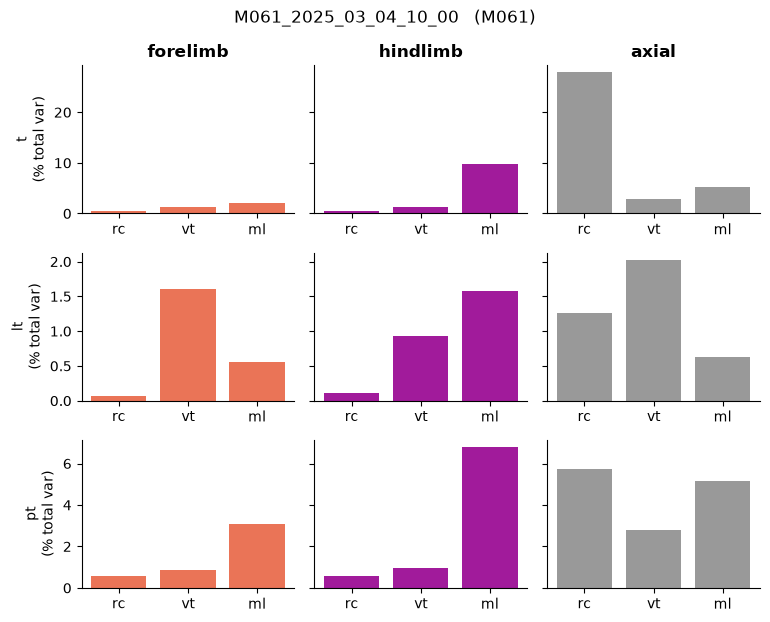

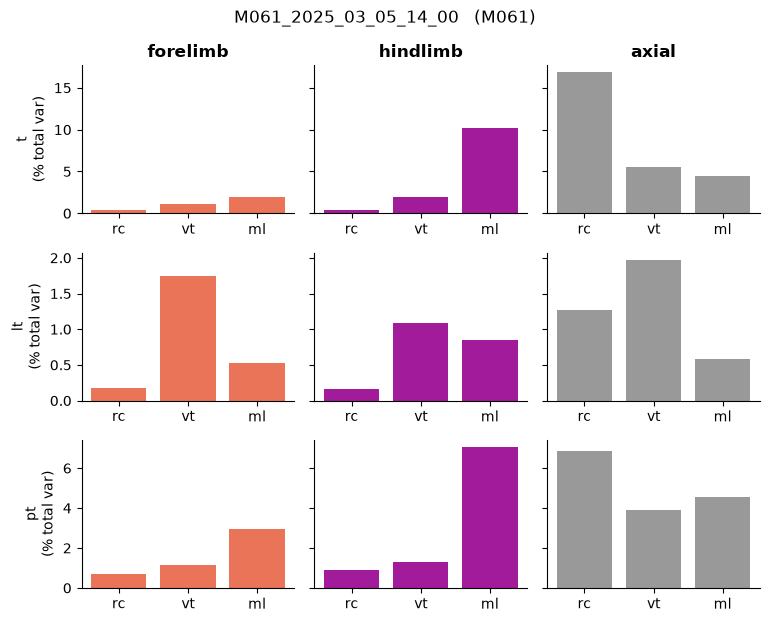

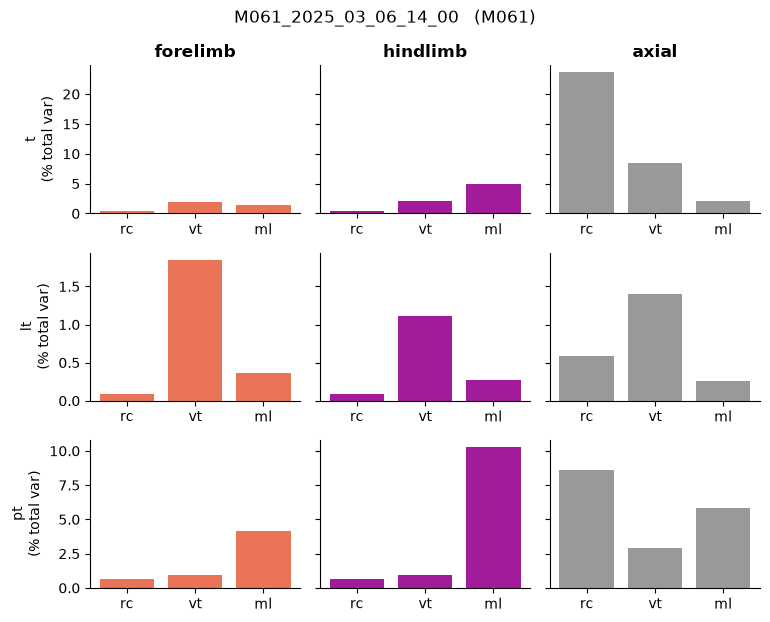

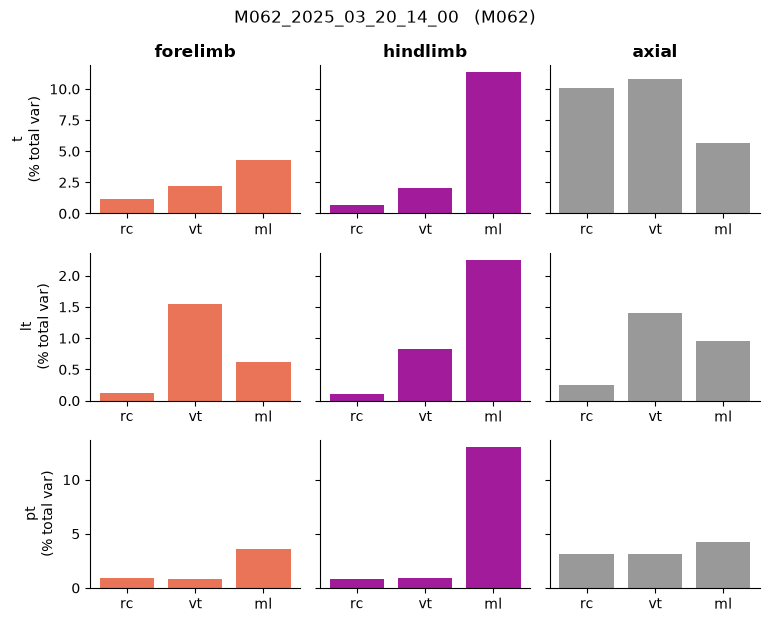

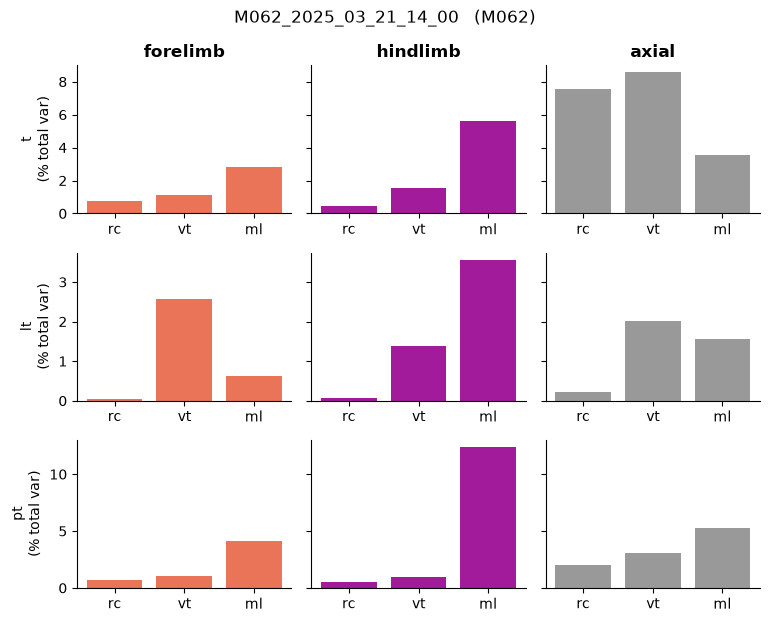

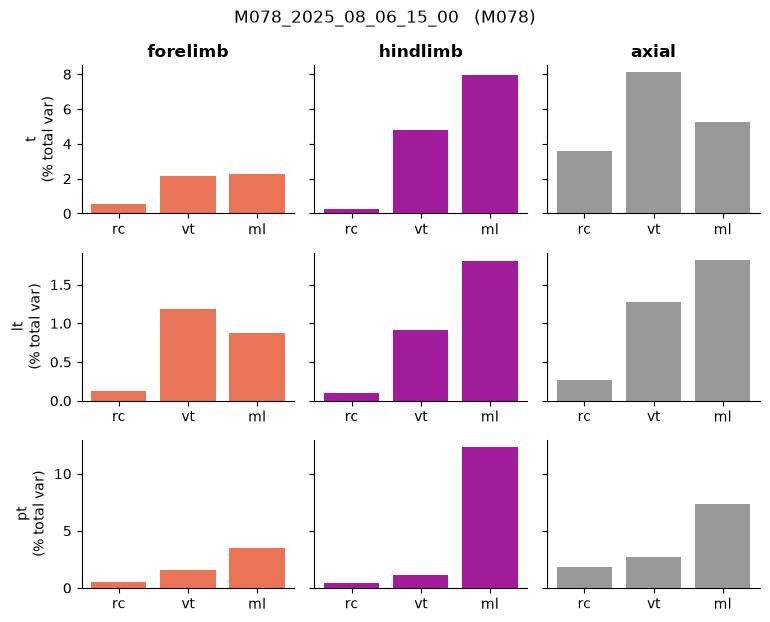

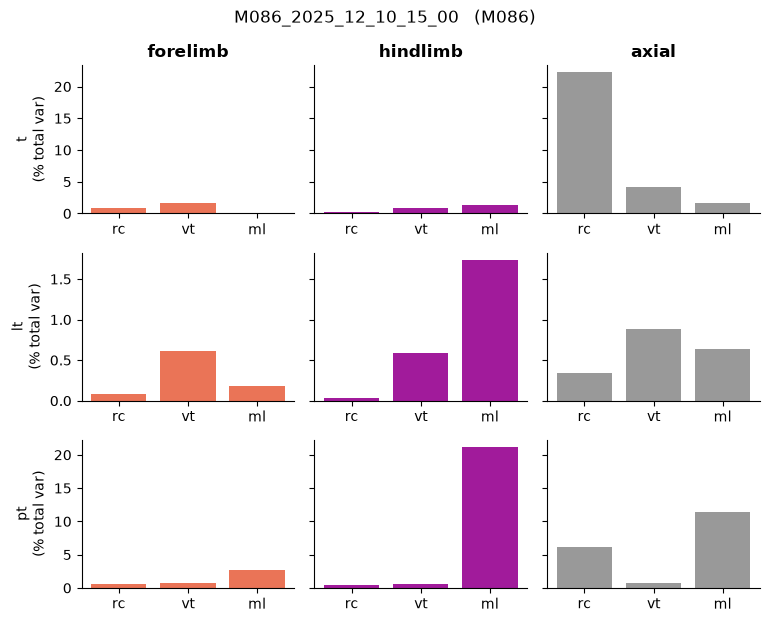

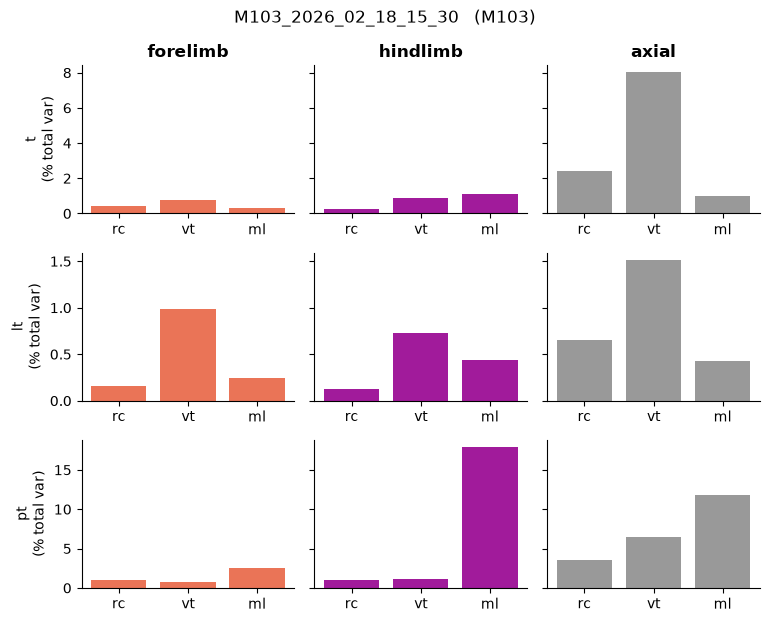

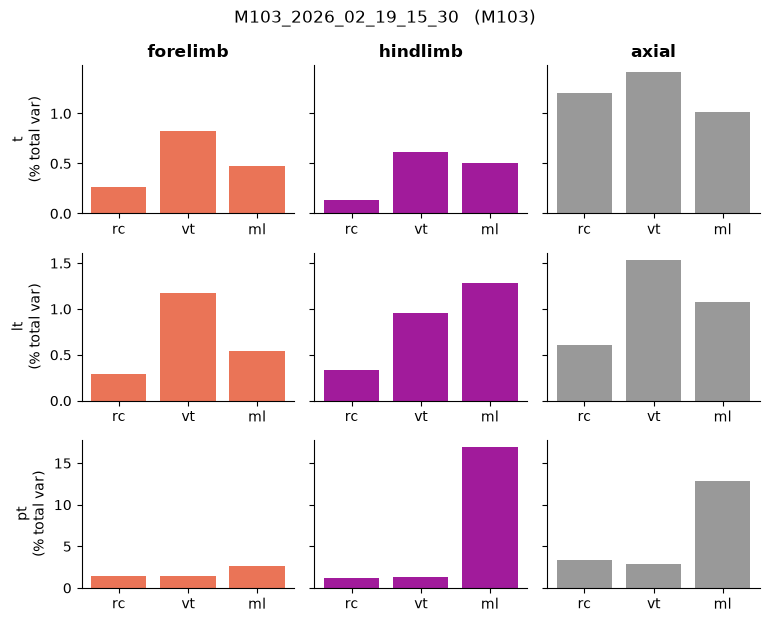

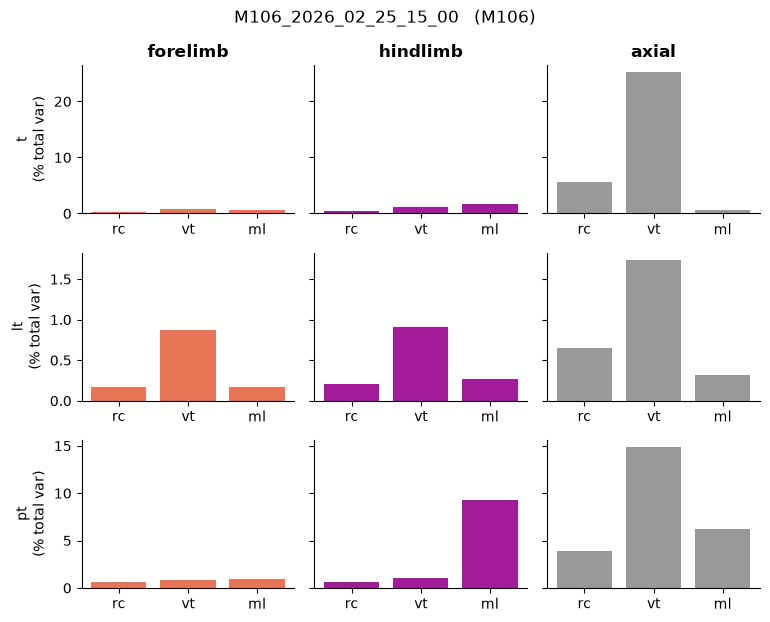

In [26]:
# one 3x3 grid per session
for s, T in zip(sessions, Tall):
    plot_region_dim(T, f"{s}   ({s.split('_')[0]})")


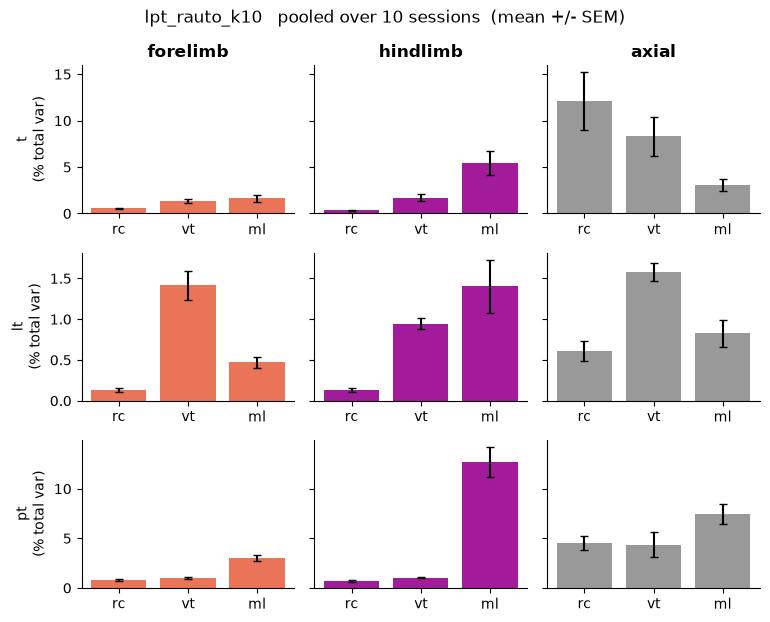

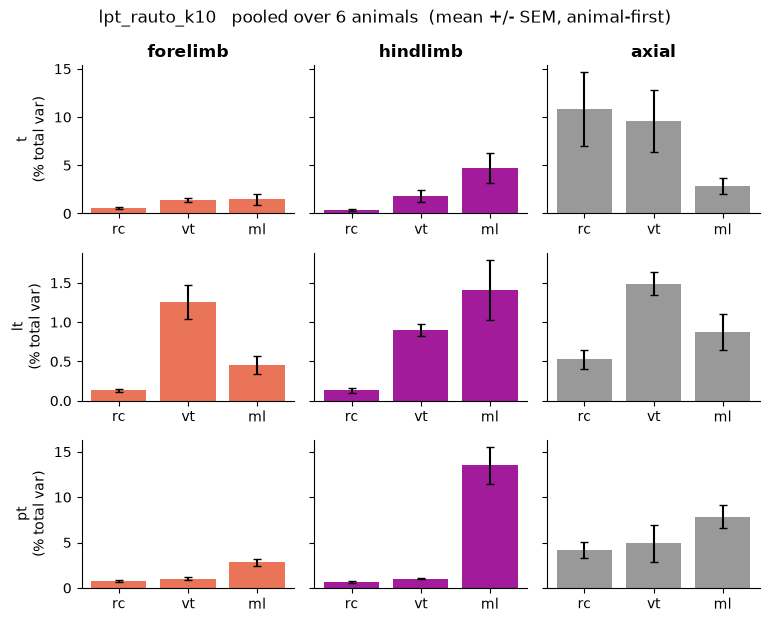

In [140]:
# aggregated: pooled over sessions, and pooled over animals (mean within animal first)
sem = lambda A: A.std(0, ddof=1) / np.sqrt(A.shape[0])

plot_region_dim(Tall.mean(0), f"{RUN_TAG}   pooled over {len(sessions)} sessions  (mean +/- SEM)",
                err=sem(Tall))

animals = np.array([s.split("_")[0] for s in sessions])
uniq = sorted(set(animals))
Tanim = np.stack([Tall[animals == a].mean(0) for a in uniq])        # (n_animals, marg, group, dim)
plot_region_dim(Tanim.mean(0), f"{RUN_TAG}   pooled over {len(uniq)} animals  (mean +/- SEM, animal-first)",
                err=sem(Tanim))
